# **SEQUENCE MODEL FILTER COMPARISON (NONLINEAR): SPHERICAL PENDULUM — MISTRAL vs GPT2 vs MAMBA vs EKF**
## Run all code blocks sequentially

State `x = [theta, phi, theta_dot, phi_dot]` of a spherical pendulum evolves with

```
theta_ddot = sin(theta) cos(theta) phi_dot^2 - (g / l) sin(theta) + tau_theta / (m l^2)
phi_ddot   = -2 cot(theta) theta_dot phi_dot + tau_phi / (m l^2 sin^2(theta))
```

with per-trajectory parameters `m, g, l ~ Uniform` and Gaussian torque inputs
`u_j ~ N(u_mean[j], u_std[j]^2)` set per dimension in `CONFIG` (default mean = std = 0,
i.e. `u = 0`). Output: `y = C x + v` with `C` a random Gaussian matrix, sampled fresh
per trajectory like in `FilteringSequenceModels.ipynb`.
The sequence models read `y` and `u` and predict `x`; the classical baseline is an EKF.

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
import pytorch_lightning as pl
from pytorch_lightning import LightningModule
from transformers import MistralModel, MistralConfig, GPT2Model, GPT2Config
from mamba_ssm import Mamba2 as Mamba
from filterpy.kalman import KalmanFilter


# Set random seeds for reproducibility
seed = 42
global rng
rng = np.random.default_rng(seed)

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

/home/awt36/anaconda3/envs/MambaAMD/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading tilelang libs from dev root: /home/awt36/tilelang/build


Using device: cuda


In [2]:
# 2. System Dynamics Model (Spherical Pendulum)

class PendulumSim:
    """
    Spherical pendulum simulator.

    State x = [theta, phi, theta_dot, phi_dot]:
      - theta: polar angle from the downward vertical (rad), lives in (0, pi)
      - phi: azimuthal angle (rad), unwrapped
      - theta_dot, phi_dot: angular velocities (rad/s)

    Continuous-time dynamics with torque input u = [tau_theta, tau_phi]:
      theta_ddot = sin(theta) cos(theta) phi_dot^2 - (g/l) sin(theta) + tau_theta / (m l^2)
      phi_ddot   = -2 cot(theta) theta_dot phi_dot + tau_phi / (m l^2 sin^2(theta))

    Each input dimension is an independent Gaussian torque,
    u_j ~ N(u_mean[j], u_std[j]^2), j in {theta, phi} (defaults 0, i.e. u = 0).
    With u != 0 the mass m no longer cancels out of the dynamics.

    Per-trajectory parameters (sampled uniformly):
      m ~ U[m_low, m_high]  bob mass (kg)
      g ~ U[g_low, g_high]  gravitational acceleration (m/s^2)
      l ~ U[l_low, l_high]  rod length (m)

    Output equation (same structure as FilteringSequenceModels):
      y = C x + v,  v ~ N(0, sigma_v^2 I)
    C has standard normal entries and is resampled until the observability rank
    condition holds (checked against the pendulum linearized at the downward
    equilibrium, since the nonlinear system has no constant A). Process noise
    w ~ N(0, sigma_w^2 I) is added to the state once per recorded step.

    Initial conditions are drawn on "orbiting" trajectories that stay away from
    the coordinate singularities theta = 0 and theta = pi (where phi_dot diverges
    in spherical coordinates): two turning points of the effective potential are
    sampled, the corresponding conserved vertical angular momentum is solved for,
    and a random phase along the orbit is chosen (see _sample_x0).
    """

    nx = 4   # [theta, phi, theta_dot, phi_dot]
    nu = 2   # [tau_theta, tau_phi] (zero for now)

    def __init__(self, m=1.0, g=9.81, l=1.0, ny=2, sigma_w=0.01, sigma_v=0.01,
                 C=None, dt=0.05, n_substeps=5,
                 theta_min_low=0.4, theta_min_high=1.0,
                 u_mean=(0.0, 0.0), u_std=(0.0, 0.0)):
        self.m = m
        self.g = g
        self.l = l
        self.ny = ny
        self.sigma_w = sigma_w
        self.sigma_v = sigma_v
        self.dt = dt
        self.n_substeps = n_substeps
        self.theta_min_low = theta_min_low
        self.theta_min_high = theta_min_high
        self.u_mean = np.asarray(u_mean, dtype=float)
        self.u_std = np.asarray(u_std, dtype=float)

        if C is None:
            self.C = self._generate_observable_C(ny, g, l, nx=self.nx)
        else:
            self.C = C

    @staticmethod
    def _deriv(x, m, g, l, u=(0.0, 0.0)):
        """Continuous-time dynamics f(x) (+ torque input u, held at 0 for now)."""
        theta, phi, omega, nu = x
        tau_theta, tau_phi = u
        sin_th, cos_th = np.sin(theta), np.cos(theta)
        d_theta = omega
        d_phi = nu
        d_omega = sin_th * cos_th * nu**2 - (g / l) * sin_th + tau_theta / (m * l**2)
        d_nu = -2.0 * (cos_th / sin_th) * omega * nu + tau_phi / (m * l**2 * sin_th**2)
        return np.array([d_theta, d_phi, d_omega, d_nu])

    @classmethod
    def _rk4_step(cls, x, h, m, g, l, u=(0.0, 0.0)):
        """One RK4 step of size h."""
        k1 = cls._deriv(x, m, g, l, u)
        k2 = cls._deriv(x + 0.5 * h * k1, m, g, l, u)
        k3 = cls._deriv(x + 0.5 * h * k2, m, g, l, u)
        k4 = cls._deriv(x + h * k3, m, g, l, u)
        return x + (h / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

    @staticmethod
    def _continuous_jacobian(x, g, l, m=None, u=(0.0, 0.0)):
        """Jacobian of the continuous dynamics df/dx at state x (with torque u)."""
        theta, phi, omega, nu = x
        tau_theta, tau_phi = u
        sin_th, cos_th = np.sin(theta), np.cos(theta)
        A = np.zeros((4, 4))
        A[0, 2] = 1.0
        A[1, 3] = 1.0
        A[2, 0] = np.cos(2 * theta) * nu**2 - (g / l) * cos_th
        A[2, 3] = 2.0 * sin_th * cos_th * nu
        # extra d(theta)/d(theta) term from tau_phi / (m l^2 sin^2(theta))
        tau_phi_term = 0.0 if tau_phi == 0.0 else             -2.0 * tau_phi * cos_th / (m * l**2 * sin_th**3)
        A[3, 0] = 2.0 * omega * nu / sin_th**2 + tau_phi_term
        A[3, 2] = -2.0 * (cos_th / sin_th) * nu
        A[3, 3] = -2.0 * (cos_th / sin_th) * omega
        return A

    @staticmethod
    def _equilibrium_linearization(g, l):
        """A matrix of the pendulum linearized at the hanging equilibrium."""
        A = np.zeros((4, 4))
        A[0, 2] = 1.0
        A[1, 3] = 1.0
        A[2, 0] = -(g / l)
        return A

    @staticmethod
    def _generate_observable_C(ny, g, l, nx=4):
        """Random Gaussian C, resampled until the observability rank condition holds."""
        A_eq = PendulumSim._equilibrium_linearization(g, l)
        for _ in range(100):
            C = rng.standard_normal(size=(ny, nx))
            O = np.concatenate([C @ np.linalg.matrix_power(A_eq, i) for i in range(nx)], axis=0)
            if np.linalg.matrix_rank(O) == nx:
                return C.astype(np.float32)
        raise RuntimeError("Could not generate observable C matrix")

    def _sample_x0(self):
        """Sample an initial state on an orbit bounded away from the poles.

        Draws two turning points theta_min < theta_max of the effective potential
        U_eff(th) = l^2 ell^2 / (2 sin^2(th)) - g l cos(th), where
        ell = sin^2(theta) * phi_dot is the conserved vertical angular momentum
        (per unit m l^2), solves for ell, then picks a random phase along the orbit.
        """
        g, l = self.g, self.l
        while True:
            theta_min = rng.uniform(self.theta_min_low, self.theta_min_high)
            theta_max = rng.uniform(theta_min + 0.4, min(2.4, np.pi - theta_min - 0.15))
            if np.sin(theta_min) < np.sin(theta_max):
                break
        ell_sq = 2.0 * g * l * (np.cos(theta_min) - np.cos(theta_max)) / \
            (1.0 / np.sin(theta_min)**2 - 1.0 / np.sin(theta_max)**2)
        ell = rng.choice([-1.0, 1.0]) * np.sqrt(ell_sq)

        def u_eff(th):
            return 0.5 * l**2 * ell**2 / np.sin(th)**2 - g * l * np.cos(th)

        eps = u_eff(theta_min)  # orbit energy (per unit mass); equals u_eff(theta_max)
        theta0 = rng.uniform(theta_min, theta_max)
        omega0 = rng.choice([-1.0, 1.0]) * np.sqrt(max(2.0 * (eps - u_eff(theta0)) / l**2, 0.0))
        phi0 = rng.uniform(-np.pi, np.pi)
        nu0 = ell / np.sin(theta0)**2
        return np.array([theta0, phi0, omega0, nu0])

    def _check_state(self, x):
        """Reject states that hit the coordinate singularities or blow up."""
        theta, phi, omega, nu = x
        if not np.all(np.isfinite(x)):
            raise RuntimeError("non-finite state")
        if theta <= 0.05 or theta >= np.pi - 0.05:
            raise RuntimeError("theta hit coordinate singularity")
        if max(abs(omega), abs(nu)) > 20.0:
            raise RuntimeError("angular velocity blow-up")

    def simulate(self, traj_len, x0=None):
        """
        Simulate a trajectory.

        Args:
            traj_len: number of time steps (of length dt seconds)
            x0: initial state (if None, sampled)

        Returns:
            states: (traj_len+1, nx) array of states
            outputs: (traj_len+1, ny) array of noisy observations
            inputs: (traj_len, nu) array of sampled torque inputs
        """
        x = self._sample_x0() if x0 is None else np.asarray(x0, dtype=float)
        self._check_state(x)
        states = [x]
        outputs = [self.C @ x + rng.standard_normal(self.ny) * self.sigma_v]
        inputs = []
        h = self.dt / self.n_substeps

        for _ in range(traj_len):
            # Gaussian torque input per dimension; zero std keeps u deterministic
            # (and skips the RNG draw so the u=0 stream is unchanged)
            if np.all(self.u_std == 0.0):
                u = self.u_mean.copy()
            else:
                u = rng.normal(self.u_mean, self.u_std, size=self.nu)
            inputs.append(u)

            # Deterministic RK4 integration over dt, then discrete process noise
            for _ in range(self.n_substeps):
                x = self._rk4_step(x, h, self.m, self.g, self.l, u)
            x = x + rng.standard_normal(self.nx) * self.sigma_w
            self._check_state(x)
            states.append(x)

            y = self.C @ x + rng.standard_normal(self.ny) * self.sigma_v
            outputs.append(y)

        return (np.array(states, dtype=np.float32),
                np.array(outputs, dtype=np.float32),
                np.array(inputs, dtype=np.float32))


def apply_ekf_filter(m, g, l, C, obs, inputs, dt=0.05, n_substeps=5,
                     x0=None, P0=None, sigma_w=None, sigma_v=None):
    """
    Extended Kalman filter for the spherical pendulum (knows m, g, l, C, the applied
    torque inputs u and the noise levels exactly, mirroring the Kalman filter baseline
    in FilteringSequenceModels). The mean is propagated with the nonlinear RK4 map
    including u; the covariance with the linearized discrete map F ~ I + dt A + (dt^2/2) A^2.

    The estimate is clamped to the physically valid region (theta away from the
    coordinate singularities, bounded velocities) to keep the csc^2(theta) terms
    in the Jacobian from destabilizing the filter on bad linearization points,
    and the process noise is inflated to let the filter recover from them
    (standard robustification for linearization error).
    """
    ny, nx = np.asarray(C).shape
    sigma_w = 0.01 if sigma_w is None else sigma_w
    sigma_v = 0.01 if sigma_v is None else sigma_v

    kf = KalmanFilter(dim_x=nx, dim_z=ny)
    # Q inflated 100x: linearization error acts like extra process noise, and
    # without it the filter occasionally locks onto a wrong orbit and never
    # recovers (its covariance has collapsed)
    kf.Q = np.eye(nx) * sigma_w**2 * 100.0
    kf.R = np.eye(ny) * sigma_v**2
    # generous initial covariance reflecting the actual initial-state spread
    kf.P = np.diag([0.5, np.pi**2 / 3, 4.0, 9.0]) if P0 is None else P0
    # a zero initial state would sit exactly on the coordinate singularity theta = 0
    kf.x = np.array([1.0, 0.0, 0.0, 0.0]) if x0 is None else np.asarray(x0, dtype=float)
    kf.H = np.asarray(C, dtype=float)
    kf.inv = np.linalg.pinv  # guard against a singular innovation covariance

    def clip_state(x):
        x[0] = np.clip(x[0], 0.15, np.pi - 0.15)
        x[2] = np.clip(x[2], -20.0, 20.0)
        x[3] = np.clip(x[3], -20.0, 20.0)
        return x

    h = dt / n_substeps
    kf_states = []

    # Process first observation y_0 to estimate x_0
    if len(obs) > 0:
        kf.update(obs[0])
        kf_states.append(kf.x.copy())

    # Process remaining observations: predict with the nonlinear dynamics, update with y_{i+1}
    for i in range(len(inputs)):
        u_i = inputs[i] if inputs is not None else np.zeros(2)
        x_pred = kf.x.copy()
        for _ in range(n_substeps):
            x_pred = clip_state(PendulumSim._rk4_step(x_pred, h, m, g, l, u_i))

        # Jacobian evaluated away from the singularities so covariance stays bounded
        x_guarded = kf.x.copy()
        x_guarded[0] = np.clip(x_guarded[0], 0.2, np.pi - 0.2)
        x_guarded[2] = np.clip(x_guarded[2], -10.0, 10.0)
        x_guarded[3] = np.clip(x_guarded[3], -10.0, 10.0)
        A = PendulumSim._continuous_jacobian(x_guarded, g, l, m=m, u=u_i)
        F = np.eye(nx) + dt * A + 0.5 * dt**2 * (A @ A)

        kf.x = x_pred
        kf.P = F @ kf.P @ F.T + kf.Q
        kf.P = np.minimum(kf.P, 1e6)  # numerical safety clamp
        kf.update(obs[i + 1])
        kf.x = clip_state(kf.x.copy())
        kf_states.append(kf.x.copy())

    return np.array(kf_states, dtype=np.float32)


def apply_ekf_filter_from_traj(traj):
    """
    Apply the EKF to a trajectory dictionary.

    Args:
        traj: trajectory dictionary with 'obs', 'inputs', 'm', 'g', 'l', 'C',
              'dt' (and optionally 'sigma_w', 'sigma_v')

    Returns:
        ekf_states: (traj_len+1, nx) array of EKF state estimates
    """
    return apply_ekf_filter(
        m=traj['m'], g=traj['g'], l=traj['l'], C=traj['C'],
        obs=traj['obs'], inputs=traj['inputs'], dt=traj['dt'],
        sigma_w=traj.get('sigma_w', 0.01), sigma_v=traj.get('sigma_v', 0.01))


def generate_trajectory(ny=2, traj_len=50, sigma_w=0.01, sigma_v=0.01,
                        m_low=0.5, m_high=2.0, g_low=8.0, g_high=12.0,
                        l_low=0.5, l_high=2.0, C=None,
                        dt=0.05, n_substeps=5,
                        theta_min_low=0.4, theta_min_high=1.0,
                        u_mean=(0.0, 0.0), u_std=(0.0, 0.0), max_tries=20):
    """
    Generate a single trajectory with per-trajectory m, g, l ~ Uniform and its
    own output matrix C (sampled fresh here unless one is provided). Inputs are
    Gaussian per dimension: u_j ~ N(u_mean[j], u_std[j]^2).

    Returns:
        dict with 'states', 'obs', 'inputs', 'm', 'g', 'l', 'C',
        'sigma_w', 'sigma_v', 'dt'
    """
    for _ in range(max_tries):
        m = rng.uniform(m_low, m_high)
        g = rng.uniform(g_low, g_high)
        l = rng.uniform(l_low, l_high)
        fsim = PendulumSim(m=m, g=g, l=l, ny=ny, sigma_w=sigma_w, sigma_v=sigma_v,
                           C=C, dt=dt, n_substeps=n_substeps,
                           theta_min_low=theta_min_low, theta_min_high=theta_min_high,
                           u_mean=u_mean, u_std=u_std)
        try:
            states, obs, inputs = fsim.simulate(traj_len)
        except RuntimeError:
            continue  # trajectory crossed a coordinate singularity; resample
        return {
            'states': states,
            'obs': obs,
            'inputs': inputs,
            'm': m,
            'g': g,
            'l': l,
            'C': fsim.C,
            'sigma_w': sigma_w,
            'sigma_v': sigma_v,
            'dt': dt,
        }
    raise RuntimeError("Could not generate a valid trajectory")

In [3]:
# 3. Dataset Preparation

class TrajectoryDataset(Dataset):
    """
    Dataset that provides trajectories for training.
    Each sample is a trajectory with states, observations, and inputs.
    """

    def __init__(self, trajectories):
        """
        Args:
            trajectories: list of trajectory dicts from generate_trajectory()
        """
        self.trajectories = trajectories

    def __len__(self):
        return len(self.trajectories)

    def __getitem__(self, idx):
        """
        Returns a sample dict with:
        - xs: input features (concatenated observation and input)
        - ys: target (state)
        """
        traj = self.trajectories[idx % len(self.trajectories)]

        states = traj['states']  # (traj_len+1, nx)
        obs = traj['obs']  # (traj_len+1, ny)
        inputs = traj['inputs']  # (traj_len, nu), all zeros for now

        # Input: [output_t, input_{t-1}], Target: state_t
        # Use noisy observations and previous input as input (filtering: estimate state from observation and input)
        xs = np.concatenate([obs[1:], inputs], axis=-1)  # (traj_len, ny+nu)
        ys = states[1:]  # (traj_len, nx)

        return {
            'xs': torch.from_numpy(xs).float(),
            'ys': torch.from_numpy(ys).float()
        }


def create_datasets(num_train=1000, num_val=200, traj_len=50,
                    ny=2, sigma_w=0.01, sigma_v=0.01,
                    m_low=0.5, m_high=2.0, g_low=8.0, g_high=12.0,
                    l_low=0.5, l_high=2.0,
                    dt=0.05, n_substeps=5,
                    theta_min_low=0.4, theta_min_high=1.0,
                    u_mean=(0.0, 0.0), u_std=(0.0, 0.0)):
    """
    Create training and validation datasets. Each trajectory gets its own
    m, g, l and output matrix C, all sampled independently per trajectory.

    Returns:
        train_dataset, val_dataset
    """
    print("Generating training trajectories...")
    train_traj = [
        generate_trajectory(ny=ny, traj_len=traj_len,
                           sigma_w=sigma_w, sigma_v=sigma_v,
                           m_low=m_low, m_high=m_high, g_low=g_low, g_high=g_high,
                           l_low=l_low, l_high=l_high,
                           dt=dt, n_substeps=n_substeps,
                           theta_min_low=theta_min_low, theta_min_high=theta_min_high,
                           u_mean=u_mean, u_std=u_std)
        for _ in tqdm(range(num_train))
    ]
    print("Generating validation trajectories...")
    val_traj = [
        generate_trajectory(ny=ny, traj_len=traj_len,
                           sigma_w=sigma_w, sigma_v=sigma_v,
                           m_low=m_low, m_high=m_high, g_low=g_low, g_high=g_high,
                           l_low=l_low, l_high=l_high,
                           dt=dt, n_substeps=n_substeps,
                           theta_min_low=theta_min_low, theta_min_high=theta_min_high,
                           u_mean=u_mean, u_std=u_std)
        for _ in tqdm(range(num_val))
    ]
    return TrajectoryDataset(train_traj), TrajectoryDataset(val_traj)

In [4]:
# 4a. Mistral Transformer Model

class Mistral7BFilter(LightningModule):
    """
    Transformer model using HuggingFace Mistral for sequence prediction.
    Trained with PyTorch Lightning.
    Based on the original repository's approach.
    """

    def __init__(self, input_dim, output_dim, n_positions=50,
                 n_embd=128, n_layer=6, n_head=4, dropout=0.15,
                 learning_rate=1e-4, weight_decay=1e-4, gradient_clip=1.0):
        """
        Args:
            input_dim: dimension of input features
            output_dim: dimension of output (state dimension)
            n_positions: maximum sequence length
            n_embd: embedding dimension
            n_layer: number of transformer layers
            n_head: number of attention heads
            dropout: dropout rate
            learning_rate: learning rate for optimizer
            weight_decay: weight decay for optimizer
            gradient_clip: gradient clipping value
        """
        super().__init__()
        self.save_hyperparameters()

        self.input_dim = input_dim
        self.output_dim = output_dim
        self.n_positions = n_positions
        self.n_embd = n_embd
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.gradient_clip = gradient_clip

        # Input embedding (projects input features to embedding dimension)
        self.embed = nn.Linear(input_dim, n_embd)

        # Mistral configuration
        mistral_config = MistralConfig(
            vocab_size=1,  # Not used, we have our own embeddings
            max_position_embeddings=n_positions,
            hidden_size=n_embd,
            num_hidden_layers=n_layer,
            num_attention_heads=n_head,
            num_key_value_heads=n_head,  # Mistral uses GQA by default
            intermediate_size=n_embd * 4,  # Typical for Mistral
            hidden_dropout=dropout,
            attention_dropout=dropout,
            use_cache=False,
        )

        # Mistral model (without the final LM head)
        self.transformer = MistralModel(mistral_config)

        # Output projection
        self.output_proj = nn.Linear(n_embd, output_dim)

        # Loss function
        self.criterion = nn.MSELoss()

    def forward(self, xs):
        """
        Args:
            xs: (batch_size, seq_len, input_dim) input tensor

        Returns:
            preds: (batch_size, seq_len, output_dim) predictions
        """
        batch_size, seq_len, _ = xs.shape

        # Input embedding
        x = self.embed(xs)

        # Truncate if sequence is too long
        if seq_len > self.n_positions:
            x = x[:, -self.n_positions:]

        # Mistral expects inputs_embeds, not tokenizer input
        # Mistral has built-in positional embeddings and causal mask
        output = self.transformer(inputs_embeds=x).last_hidden_state

        # Output projection
        preds = self.output_proj(output)

        return preds

    def training_step(self, batch, batch_idx):
        xs = batch['xs']
        ys = batch['ys']

        preds = self(xs)

        # Handle potential length mismatch
        min_len = min(preds.shape[1], ys.shape[1])
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])

        self.log('train_loss', loss, prog_bar=True, on_step=True, on_epoch=True, sync_dist=True)
        return loss

    def validation_step(self, batch, batch_idx):
        xs = batch['xs']
        ys = batch['ys']

        preds = self(xs)

        # Handle potential length mismatch
        min_len = min(preds.shape[1], ys.shape[1])
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])

        self.log('val_loss', loss, prog_bar=True, on_step=False, on_epoch=True, sync_dist=True)
        return loss

    def test_step(self, batch, batch_idx):
        xs = batch['xs']
        ys = batch['ys']

        preds = self(xs)

        # Handle potential length mismatch
        min_len = min(preds.shape[1], ys.shape[1])
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])

        self.log('test_loss', loss, on_step=False, on_epoch=True, sync_dist=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.learning_rate,
            weight_decay=self.weight_decay
        )
        return {
            'optimizer': optimizer,
            'clip_value': self.gradient_clip,
        }

# 4b. GPT2 Transformer Model

class GPT2Filter(LightningModule):
    """
    Transformer model using HuggingFace GPT2 for sequence prediction.
    Trained with PyTorch Lightning.
    """

    def __init__(self, input_dim, output_dim, n_positions=50,
                 n_embd=256, n_layer=12, n_head=8, dropout=0.1,
                 learning_rate=3e-4, weight_decay=1e-2, gradient_clip=1.0):
        """
        Args:
            input_dim: dimension of input features
            output_dim: dimension of output (state dimension)
            n_positions: maximum sequence length
            n_embd: embedding dimension
            n_layer: number of transformer layers
            n_head: number of attention heads
            dropout: dropout rate
            learning_rate: learning rate
            weight_decay: weight decay
            gradient_clip: gradient clipping value
        """
        super().__init__()
        self.save_hyperparameters()

        self.input_dim = input_dim
        self.output_dim = output_dim
        self.n_positions = n_positions
        self.n_embd = n_embd
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.gradient_clip = gradient_clip

        self.embed = nn.Linear(input_dim, n_embd)

        gpt2_config = GPT2Config(
            n_positions=2048,
            n_embd=n_embd,
            n_layer=n_layer,
            n_head=n_head,
            resid_pdrop=0.0,
            embd_pdrop=0.0,
            attn_pdrop=0.0,
            use_cache=False,
        )

        self.transformer = GPT2Model(gpt2_config)

        self.output_proj = nn.Linear(n_embd, output_dim)

        self.criterion = nn.MSELoss()

    def forward(self, xs):
        """
        Args:
            xs: (batch_size, seq_len, input_dim)

        Returns:
            preds: (batch_size, seq_len, output_dim)
        """
        batch_size, seq_len, _ = xs.shape
        x = self.embed(xs)
        if seq_len > self.n_positions:
            x = x[:, -self.n_positions:]
        output = self.transformer(inputs_embeds=x).last_hidden_state
        preds = self.output_proj(output)
        return preds

    def training_step(self, batch, batch_idx):
        xs = batch['xs']
        ys = batch['ys']
        preds = self(xs)
        min_len = min(preds.shape[1], ys.shape[1])
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])
        self.log('train_loss', loss, prog_bar=True, on_step=True, on_epoch=True, sync_dist=True)
        return loss

    def validation_step(self, batch, batch_idx):
        xs = batch['xs']
        ys = batch['ys']
        preds = self(xs)
        min_len = min(preds.shape[1], ys.shape[1])
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])
        self.log('val_loss', loss, prog_bar=True, on_step=False, on_epoch=True, sync_dist=True)
        return loss

    def test_step(self, batch, batch_idx):
        xs = batch['xs']
        ys = batch['ys']
        preds = self(xs)
        min_len = min(preds.shape[1], ys.shape[1])
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])
        self.log('test_loss', loss, on_step=False, on_epoch=True, sync_dist=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.learning_rate,
            weight_decay=self.weight_decay
        )
        return {
            'optimizer': optimizer,
            'clip_value': self.gradient_clip,
        }

# 4c. Mamba SSM Model

class MambaFilter(LightningModule):
    """
    Mamba SSM model for sequence prediction.
    Trained with PyTorch Lightning.
    Based on the original repository's approach but using Mamba instead of Transformer.
    """

    def __init__(self, input_dim, output_dim, n_positions=50,
                 d_model=256, n_layers=4, d_state=16, d_conv=4, expand=2,
                 learning_rate=1e-4, weight_decay=1e-4, gradient_clip=1.0):
        """
        Args:
            input_dim: dimension of input features
            output_dim: dimension of output (state dimension)
            n_positions: maximum sequence length
            d_model: model dimension
            n_layers: number of Mamba layers
            d_state: state dimension for Mamba
            d_conv: convolution dimension for Mamba
            expand: expansion factor for Mamba
            learning_rate: learning rate for optimizer
            weight_decay: weight decay for optimizer
            gradient_clip: gradient clipping value
        """
        super().__init__()
        self.save_hyperparameters()

        self.input_dim = input_dim
        self.output_dim = output_dim
        self.n_positions = n_positions
        self.d_model = d_model
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.gradient_clip = gradient_clip

        # Input projection to model dimension
        self.input_proj = nn.Linear(input_dim, d_model)

        # Layer norm for input
        self.input_ln = nn.LayerNorm(d_model)

        # Mamba SSM layers
        self.mamba_layers = nn.ModuleList([
            Mamba(
                d_model=d_model,
                d_state=d_state,
                d_conv=d_conv,
                expand=expand
            ) for _ in range(n_layers)
        ])

        # Layer norm between layers
        self.layer_norms = nn.ModuleList([nn.LayerNorm(d_model) for _ in range(n_layers)])

        # Output projection
        self.output_proj = nn.Linear(d_model, output_dim)

        # Loss function
        self.criterion = nn.MSELoss()

        # Initialize weights properly
        self.apply(self._init_weights)
        # Force all submodules to train mode
        self.train()

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)

    def forward(self, xs):
        """
        Args:
            xs: (batch_size, seq_len, input_dim) input tensor

        Returns:
            preds: (batch_size, seq_len, output_dim) predictions
        """
        batch_size, seq_len, _ = xs.shape

        # Input projection
        x = self.input_proj(xs)  # (batch_size, seq_len, d_model)
        x = self.input_ln(x)

        # Truncate if sequence is too long
        if seq_len > self.n_positions:
            x = x[:, -self.n_positions:]

        # Apply Mamba layers with layer norm
        for i, layer in enumerate(self.mamba_layers):
            x = layer(x)
            x = self.layer_norms[i](x)

        # Output projection
        preds = self.output_proj(x)

        return preds

    def training_step(self, batch, batch_idx):
        xs = batch['xs']
        ys = batch['ys']

        preds = self(xs)

        # Handle potential length mismatch
        min_len = min(preds.shape[1], ys.shape[1])
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])

        self.log('train_loss', loss, prog_bar=True, on_step=True, on_epoch=True, sync_dist=True)
        return loss

    def validation_step(self, batch, batch_idx):
        xs = batch['xs']
        ys = batch['ys']

        preds = self(xs)

        # Handle potential length mismatch
        min_len = min(preds.shape[1], ys.shape[1])
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])

        self.log('val_loss', loss, prog_bar=True, on_step=False, on_epoch=True, sync_dist=True)
        return loss

    def test_step(self, batch, batch_idx):
        xs = batch['xs']
        ys = batch['ys']

        preds = self(xs)

        # Handle potential length mismatch
        min_len = min(preds.shape[1], ys.shape[1])
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])

        self.log('test_loss', loss, on_step=False, on_epoch=True, sync_dist=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.learning_rate,
            weight_decay=self.weight_decay
        )
        return {
            'optimizer': optimizer,
            'clip_value': self.gradient_clip,
        }


In [5]:
# 5. Training Setup

class TransformerDataModule(pl.LightningDataModule):
    """Lightning data module for trajectory data."""

    def __init__(self, train_dataset, val_dataset=None, batch_size=32, num_workers=4):
        super().__init__()
        self.train_dataset = train_dataset
        self.val_dataset = val_dataset
        self.batch_size = batch_size
        self.num_workers = num_workers

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            pin_memory=False,
            drop_last=False
        )

    def val_dataloader(self):
        if self.val_dataset is not None:
            return DataLoader(
                self.val_dataset,
                batch_size=self.batch_size,
                shuffle=False,
                num_workers=self.num_workers,
                pin_memory=False,
                drop_last=False
            )
        return None

    def test_dataloader(self):
        if hasattr(self, 'test_dataset') and self.test_dataset is not None:
            return DataLoader(
                self.test_dataset,
                batch_size=self.batch_size,
                shuffle=False,
                num_workers=self.num_workers,
                pin_memory=True,
                drop_last=False
            )
        return None

In [6]:
# 6. Evaluate Model on Trajectories

def evaluate_model(model, dataset, batch_size=32):
    """
    Evaluate model on a dataset.

    Args:
        model: trained LitTransformer
        dataset: TrajectoryDataset to evaluate on
        batch_size: batch size for evaluation

    Returns:
        average summed L2 norm
    """
    model = model.to(device)
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    criterion = nn.MSELoss()
    total_loss = 0.0
    num_batches = 0

    with torch.no_grad():
        for batch in loader:
            xs = batch['xs'].to(device)
            ys = batch['ys'].to(device)

            preds = model(xs)
            min_len = min(preds.shape[1], ys.shape[1])
            loss = criterion(preds[:, :min_len], ys[:, :min_len])

            total_loss += loss.item()
            num_batches += 1

    return total_loss / num_batches


def generate_test_trajectories(num_test=100, traj_len=50, ny=2,
                                sigma_w=0.01, sigma_v=0.01,
                                m_low=0.5, m_high=2.0, g_low=8.0, g_high=12.0,
                                l_low=0.5, l_high=2.0,
                                dt=0.05, n_substeps=5,
                                theta_min_low=0.4, theta_min_high=1.0,
                                u_mean=(0.0, 0.0), u_std=(0.0, 0.0)):
    """
    Generate test trajectories with potentially different parameters than training.

    Args:
        num_test: number of test trajectories
        traj_len: length of each trajectory
        ny: output dimension
        sigma_w, sigma_v: noise parameters (can differ from training)
        m_low/m_high, g_low/g_high, l_low/l_high: pendulum parameter ranges
            (can differ from training)
        u_mean, u_std: per-dimension Gaussian input mean/std (can differ from training)

    Returns:
        list of test trajectory dicts
    """
    print(f"\nGenerating {num_test} test trajectories...")
    test_traj = [
        generate_trajectory(ny=ny, traj_len=traj_len,
                           sigma_w=sigma_w, sigma_v=sigma_v,
                           m_low=m_low, m_high=m_high, g_low=g_low, g_high=g_high,
                           l_low=l_low, l_high=l_high,
                           dt=dt, n_substeps=n_substeps,
                           theta_min_low=theta_min_low, theta_min_high=theta_min_high,
                           u_mean=u_mean, u_std=u_std)
        for _ in tqdm(range(num_test))
    ]
    return test_traj


def plot_results(history, test_loss=None, save_path=None):
    """Plot training and validation loss."""
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    if 'val_loss' in history and history['val_loss']:
        plt.plot(history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('L2 Norm Loss')
    plt.legend()
    plt.title('Training History')

    if test_loss is not None:
        plt.subplot(1, 2, 2)
        plt.bar(['Test Loss'], [test_loss])
        plt.title('Test Performance')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
        print(f"Plot saved to {save_path}")
    else:
        try:
            plt.show()
        except:
            # Non-interactive backend, skip show
            pass

# **2) START EDITING PARAMETERS HERE**


In [7]:
# Configuration parameters
CONFIG = {
    # System dimensions
    'nx': 4,            # state dimension: [theta, phi, theta_dot, phi_dot]
    'ny': 2,            # output dimension
    'nu': 2,            # input dimension [tau_theta, tau_phi] (zero for now)

    # Trajectory parameters
    'traj_len': 50,     # Length of each trajectory
    'num_train': 15000,  # Number of training trajectories
    'num_val': 3750,     # Number of validation trajectories
    'num_test': 5000,    # Number of test trajectories

    # Integration parameters
    'dt': 0.05,         # Seconds between recorded steps
    'n_substeps': 5,    # RK4 substeps per recorded step

    # Pendulum parameter sampling ranges (training): m, g, l ~ Uniform
    'm_low_train': 0.5,   # mass lower bound (kg)
    'm_high_train': 2.0,  # mass upper bound (kg)
    'g_low_train': 8.0,   # gravity lower bound (m/s^2)
    'g_high_train': 12.0, # gravity upper bound (m/s^2)
    'l_low_train': 0.5,   # rod length lower bound (m)
    'l_high_train': 2.0,  # rod length upper bound (m)

    # Pendulum parameter sampling ranges (testing) - can be different!
    'm_low_test': 0.5,   # mass lower bound (kg)
    'm_high_test': 2.0,  # mass upper bound (kg)
    'g_low_test': 8.0,   # gravity lower bound (m/s^2)
    'g_high_test': 12.0, # gravity upper bound (m/s^2)
    'l_low_test': 0.5,   # rod length lower bound (m)
    'l_high_test': 2.0,  # rod length upper bound (m)

    # Input sampling: u_j ~ N(u_mean[j], u_std[j]^2) per input dimension
    # [tau_theta, tau_phi] (std = 0 keeps u deterministic, i.e. u = u_mean)
    'u_mean_train': [0.0, 0.0],
    'u_std_train': [0.0, 0.0],
    'u_mean_test': [0.0, 0.0],
    'u_std_test': [0.0, 0.0],

    # Initial-condition sampling (orbiting regime, see PendulumSim._sample_x0)
    'theta_min_low': 0.4,   # lower bound for inner turning point (rad)
    'theta_min_high': 1.0,  # upper bound for inner turning point (rad)

    # Noise parameters (training)
    'sigma_w_train': 0.01,  # Process noise
    'sigma_v_train': 0.01,  # Measurement noise
    # Noise parameters (testing) - can be different!
    'sigma_w_test': 0.01,   # Process noise for testing
    'sigma_v_test': 0.01,   # Measurement noise for testing

    # Mistral Model parameters
    'n_positions': 50,   # Maximum sequence length
    'n_embd': 128,        # Embedding dimension
    'n_layer': 6,         # Number of transformer layers
    'n_head': 4,          # Number of attention heads
    'dropout': 0.15,       # Dropout rate

    # GPT2 Model parameters
    'gpt2_n_embd': 128,
    'gpt2_n_layer': 6,
    'gpt2_n_head': 4,
    'gpt2_dropout': 0.1,
    'gpt2_learning_rate': 1e-4,
    'gpt2_weight_decay': 1e-4,

    # Mamba Model parameters
    'd_model': 128,
    'n_layers': 6,
    'd_state': 16,
    'd_conv': 4,
    'expand': 2,
    'mamba_learning_rate': 1e-4,
    'mamba_weight_decay': 1e-4,
    'mamba_dropout': 0.1,

    # Training parameters
    'batch_size': 32,
    'num_epochs': 50,
    'learning_rate': 1e-4,
    'weight_decay': 1e-4,
    'gradient_clip': 1.0,
}

print("="*60)
print("SEQUENCE MODEL FILTER COMPARISON (NONLINEAR): SPHERICAL PENDULUM")
print("="*60)
print(f"Configuration: {CONFIG}")
print()

SEQUENCE MODEL FILTER COMPARISON (NONLINEAR): SPHERICAL PENDULUM
Configuration: {'nx': 4, 'ny': 2, 'nu': 2, 'traj_len': 50, 'num_train': 15000, 'num_val': 3750, 'num_test': 5000, 'dt': 0.05, 'n_substeps': 5, 'm_low_train': 0.5, 'm_high_train': 2.0, 'g_low_train': 8.0, 'g_high_train': 12.0, 'l_low_train': 0.5, 'l_high_train': 2.0, 'm_low_test': 0.5, 'm_high_test': 2.0, 'g_low_test': 8.0, 'g_high_test': 12.0, 'l_low_test': 0.5, 'l_high_test': 2.0, 'u_mean_train': [0.0, 0.0], 'u_std_train': [0.0, 0.0], 'u_mean_test': [0.0, 0.0], 'u_std_test': [0.0, 0.0], 'theta_min_low': 0.4, 'theta_min_high': 1.0, 'sigma_w_train': 0.01, 'sigma_v_train': 0.01, 'sigma_w_test': 0.01, 'sigma_v_test': 0.01, 'n_positions': 50, 'n_embd': 128, 'n_layer': 6, 'n_head': 4, 'dropout': 0.15, 'gpt2_n_embd': 128, 'gpt2_n_layer': 6, 'gpt2_n_head': 4, 'gpt2_dropout': 0.1, 'gpt2_learning_rate': 0.0001, 'gpt2_weight_decay': 0.0001, 'd_model': 128, 'n_layers': 6, 'd_state': 16, 'd_conv': 4, 'expand': 2, 'mamba_learning_rate

In [8]:
# Step 1: Create datasets
print("\n[1/4] Creating datasets...")

# Each trajectory samples its own m, g, l and its own output matrix C
# (standard normal entries, resampled until the observability rank condition
# holds against the pendulum linearized at that trajectory's parameters)

train_dataset, val_dataset = create_datasets(
    num_train=CONFIG['num_train'],
    num_val=CONFIG['num_val'],
    traj_len=CONFIG['traj_len'],
    ny=CONFIG['ny'],
    sigma_w=CONFIG['sigma_w_train'],
    sigma_v=CONFIG['sigma_v_train'],
    m_low=CONFIG['m_low_train'],
    m_high=CONFIG['m_high_train'],
    g_low=CONFIG['g_low_train'],
    g_high=CONFIG['g_high_train'],
    l_low=CONFIG['l_low_train'],
    l_high=CONFIG['l_high_train'],
    dt=CONFIG['dt'],
    n_substeps=CONFIG['n_substeps'],
    theta_min_low=CONFIG['theta_min_low'],
    theta_min_high=CONFIG['theta_min_high'],
    u_mean=CONFIG['u_mean_train'],
    u_std=CONFIG['u_std_train'],
)

# Create data loaders
train_loader = DataLoader(train_dataset,
                          batch_size=CONFIG['batch_size'],
                          shuffle=True)
val_loader = DataLoader(val_dataset,
                        batch_size=CONFIG['batch_size'],
                        shuffle=False)

print(f"Train dataset: {len(train_dataset)} trajectories")
print(f"Val dataset: {len(val_dataset)} trajectories")


[1/4] Creating datasets...
Generating training trajectories...


100%|██████████| 15000/15000 [00:59<00:00, 251.74it/s]


Generating validation trajectories...


100%|██████████| 3750/3750 [00:14<00:00, 252.36it/s]

Train dataset: 15000 trajectories
Val dataset: 3750 trajectories


In [9]:
# Step 2: Select and Create Models
print('\n[2/4] Selecting and creating models...')

# MODEL SELECTION: Choose which sequence models to train
# Set the models you want to train by uncommenting the lines below
# Options: 'mistral', 'gpt2', 'mamba'
selected_models = ['mistral', 'gpt2', 'mamba']  # Train all three models
# selected_models = ['mistral', 'gpt2']      # Train Mistral and GPT2 only
# selected_models = ['gpt2', 'mamba']        # Train GPT2 and Mamba only
# selected_models = ['mistral']              # Train Mistral only
# selected_models = ['gpt2']                # Train GPT2 only
# selected_models = ['mamba']                # Train Mamba only

print(f'Selected models: {selected_models}')

input_dim = CONFIG['ny'] + CONFIG['nu']  # models read [y_t, u_t] and predict x_t
output_dim = CONFIG['nx']

# Dictionary to store created models
models = {}
model_trainers = {}
trained_models = {}

# Create Mistral model if selected
if 'mistral' in selected_models:
    print('Creating Mistral model...')
    mistral_model = Mistral7BFilter(
        input_dim=input_dim,
        output_dim=output_dim,
        n_positions=CONFIG['n_positions'],
        n_embd=CONFIG['n_embd'],
        n_layer=CONFIG['n_layer'],
        n_head=CONFIG['n_head'],
        dropout=CONFIG['dropout'],
        learning_rate=CONFIG['learning_rate'],
        weight_decay=CONFIG['weight_decay'],
        gradient_clip=CONFIG['gradient_clip']
    )
    models['mistral'] = mistral_model
    print(f'Mistral Model: {mistral_model.__class__.__name__}')
    print(f'Mistral Parameters: {sum(p.numel() for p in mistral_model.parameters()):,}')

# Create GPT2 model if selected
if 'gpt2' in selected_models:
    print('Creating GPT2 model...')
    gpt2_model = GPT2Filter(
        input_dim=input_dim,
        output_dim=output_dim,
        n_positions=CONFIG['n_positions'],
        n_embd=CONFIG['gpt2_n_embd'],
        n_layer=CONFIG['gpt2_n_layer'],
        n_head=CONFIG['gpt2_n_head'],
        dropout=CONFIG['gpt2_dropout'],
        learning_rate=CONFIG['gpt2_learning_rate'],
        weight_decay=CONFIG['gpt2_weight_decay'],
        gradient_clip=CONFIG['gradient_clip']
    )
    models['gpt2'] = gpt2_model
    print(f'GPT2 Model: {gpt2_model.__class__.__name__}')
    print(f'GPT2 Parameters: {sum(p.numel() for p in gpt2_model.parameters()):,}')

# Create Mamba model if selected
if 'mamba' in selected_models:
    print('Creating Mamba model...')
    mamba_model = MambaFilter(
        input_dim=input_dim,
        output_dim=output_dim,
        n_positions=CONFIG['n_positions'],
        d_model=CONFIG['d_model'],
        n_layers=CONFIG['n_layers'],
        d_state=CONFIG['d_state'],
        d_conv=CONFIG['d_conv'],
        expand=CONFIG['expand'],
        learning_rate=CONFIG['mamba_learning_rate'],
        weight_decay=CONFIG['mamba_weight_decay'],
        gradient_clip=CONFIG['gradient_clip']
    )
    models['mamba'] = mamba_model
    print(f'Mamba Model: {mamba_model.__class__.__name__}')
    print(f'Mamba Parameters: {sum(p.numel() for p in mamba_model.parameters()):,}')

print(f'Total models to train: {len(models)}')

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 0), got 1. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 0), got 2. This may result in unexpected behavior.



[2/4] Selecting and creating models...
Selected models: ['mistral', 'gpt2', 'mamba']
Creating Mistral model...
Mistral Model: Mistral7BFilter
Mistral Parameters: 1,575,812
Creating GPT2 model...
GPT2 Model: GPT2Filter
GPT2 Parameters: 7,886,084
Creating Mamba model...
Mamba Model: MambaFilter
Mamba Parameters: 630,668
Total models to train: 3


In [10]:
# Step 3: Train selected models with PyTorch Lightning
print('\n[3/4] Training selected models with PyTorch Lightning...')

# Create data module
datamodule = TransformerDataModule(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    batch_size=CONFIG['batch_size'],
    num_workers=4
)

# Train each selected model
for model_name, model in models.items():
    print(f'\n  Training {model_name} model...')

    trainer = pl.Trainer(
        max_epochs=CONFIG['num_epochs'],
        devices='auto',
        accelerator='auto',
        gradient_clip_val=CONFIG['gradient_clip'],
        log_every_n_steps=10,
        enable_progress_bar=True,
        default_root_dir='.',
    )
    trainer.fit(model, datamodule=datamodule)
    print(f'{model_name} training complete. Best val loss: {trainer.callback_metrics.get("val_loss", float("inf")):.6f}')

    # Save trained model
    model_trainers[model_name] = trainer
    trained_models[model_name] = model

print('All selected models trained successfully!')

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



[3/4] Training selected models with PyTorch Lightning...

  Training mistral model...


You are using a CUDA device ('AMD Radeon RX 7900 XTX') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/awt36/anaconda3/envs/MambaAMD/lib/python3.12/site-packages/pytorch_lightning/core/optimizer.py:378: Found unsupported keys in the optimizer configuration: {'clip_value'}

  | Name        | Type         | Params | Mode 
-----------------------------------------------------
0 | embed       | Linear       | 640    | train
1 | transformer | MistralModel | 1.6 M  | train
2 | output_proj | Linear       | 516    | train
3 | criterion   | MSELoss      | 0      | train
-----------------------------------------------------
1.6 M     Trainable params
0         Non-trainable params
1.6 M     To

/home/awt36/anaconda3/envs/MambaAMD/lib/python3.12/site-packages/transformers/integrations/sdpa_attention.py:93: UserWarning: Using AOTriton backend for Efficient Attention forward... (Triggered internally at /pytorch/aten/src/ATen/native/transformers/hip/attention.hip:1452.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


Epoch 0:   0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 49: 100%|██████████| 469/469 [00:07<00:00, 63.92it/s, v_num=512, train_loss_step=35.60, val_loss=36.20, train_loss_epoch=34.20]
gpt2 training complete. Best val loss: 36.213234

  Training mamba model...


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type       | Params | Mode 
----------------------------------------------------
0 | input_proj   | Linear     | 640    | train
1 | input_ln     | LayerNorm  | 256    | train
2 | mamba_layers | ModuleList | 627 K  | train
3 | layer_norms  | ModuleList | 1.5 K  | train
4 | output_proj  | Linear     | 516    | train
5 | criterion    | MSELoss    | 0      | train
----------------------------------------------------
630 K     Trainable params
0         Non-trainable params
630 K     Total params
2.523     Total estimated model params size (MB)
48        Modules in train mode
0         Modules in eval mode


Epoch 49: 100%|██████████| 469/469 [00:14<00:00, 32.98it/s, v_num=513, train_loss_step=17.60, val_loss=44.80, train_loss_epoch=22.00]    

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 469/469 [00:14<00:00, 32.84it/s, v_num=513, train_loss_step=17.60, val_loss=44.80, train_loss_epoch=22.00]
mamba training complete. Best val loss: 44.771950
All selected models trained successfully!


In [11]:
# 7b. Load Trained Models
print('Loading trained models...')

# Dictionary to store loaded models
loaded_models = {}

for model_name in models.keys():
    if model_name == 'mistral':
        mistral_ckpt = model_trainers['mistral'].checkpoint_callback.best_model_path
        loaded_models['mistral'] = Mistral7BFilter.load_from_checkpoint(mistral_ckpt)
        loaded_models['mistral'].eval()
    elif model_name == 'gpt2':
        gpt2_ckpt = model_trainers['gpt2'].checkpoint_callback.best_model_path
        loaded_models['gpt2'] = GPT2Filter.load_from_checkpoint(gpt2_ckpt)
        loaded_models['gpt2'].eval()
    elif model_name == 'mamba':
        mamba_ckpt = model_trainers['mamba'].checkpoint_callback.best_model_path
        loaded_models['mamba'] = MambaFilter.load_from_checkpoint(mamba_ckpt)
        loaded_models['mamba'].eval()

print(f'Loaded {len(loaded_models)} models successfully.')

# Update trained_models with loaded models
trained_models = loaded_models

Loading trained models...
Loaded 3 models successfully.


Generating 5000 test trajectories for visualization...


100%|██████████| 5000/5000 [00:21<00:00, 232.81it/s]


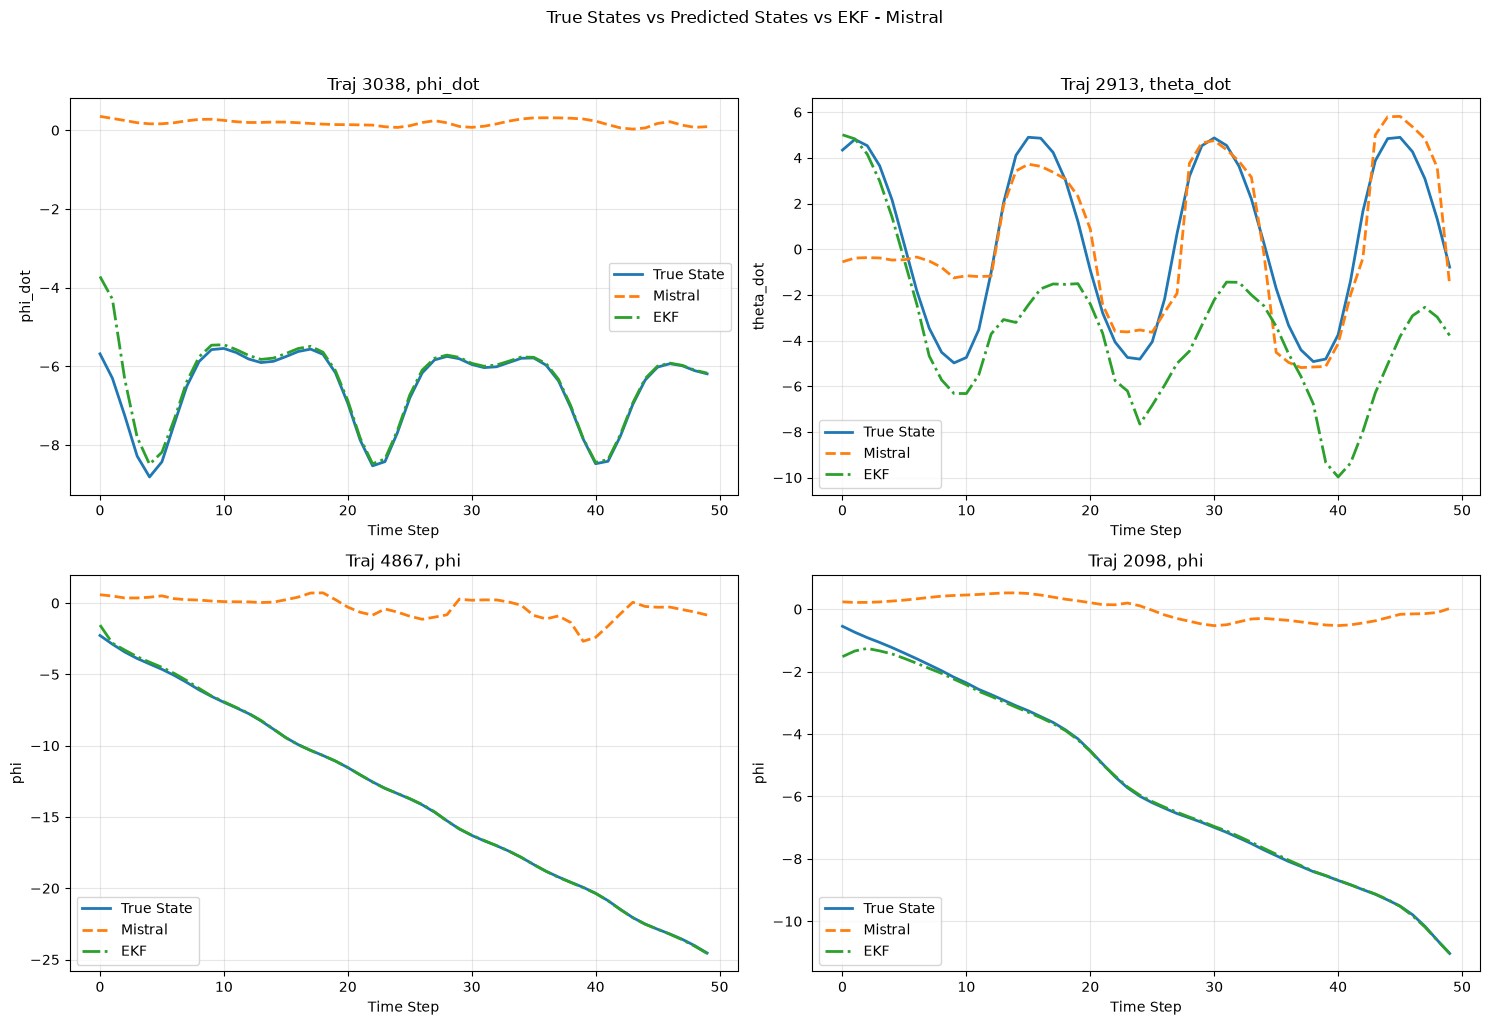

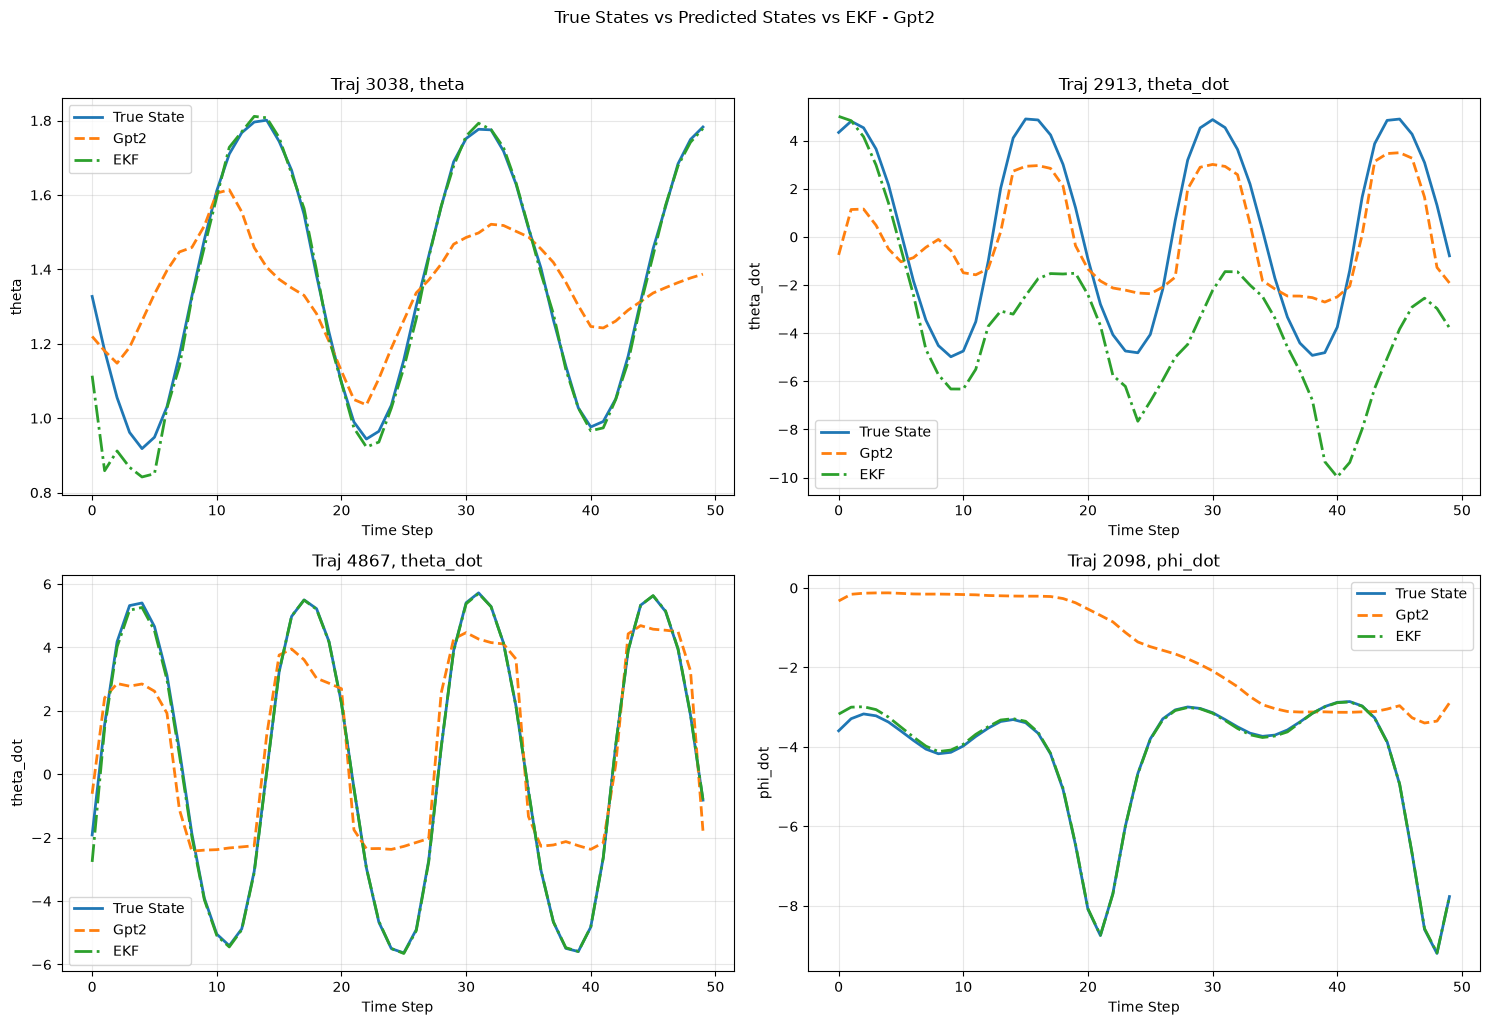

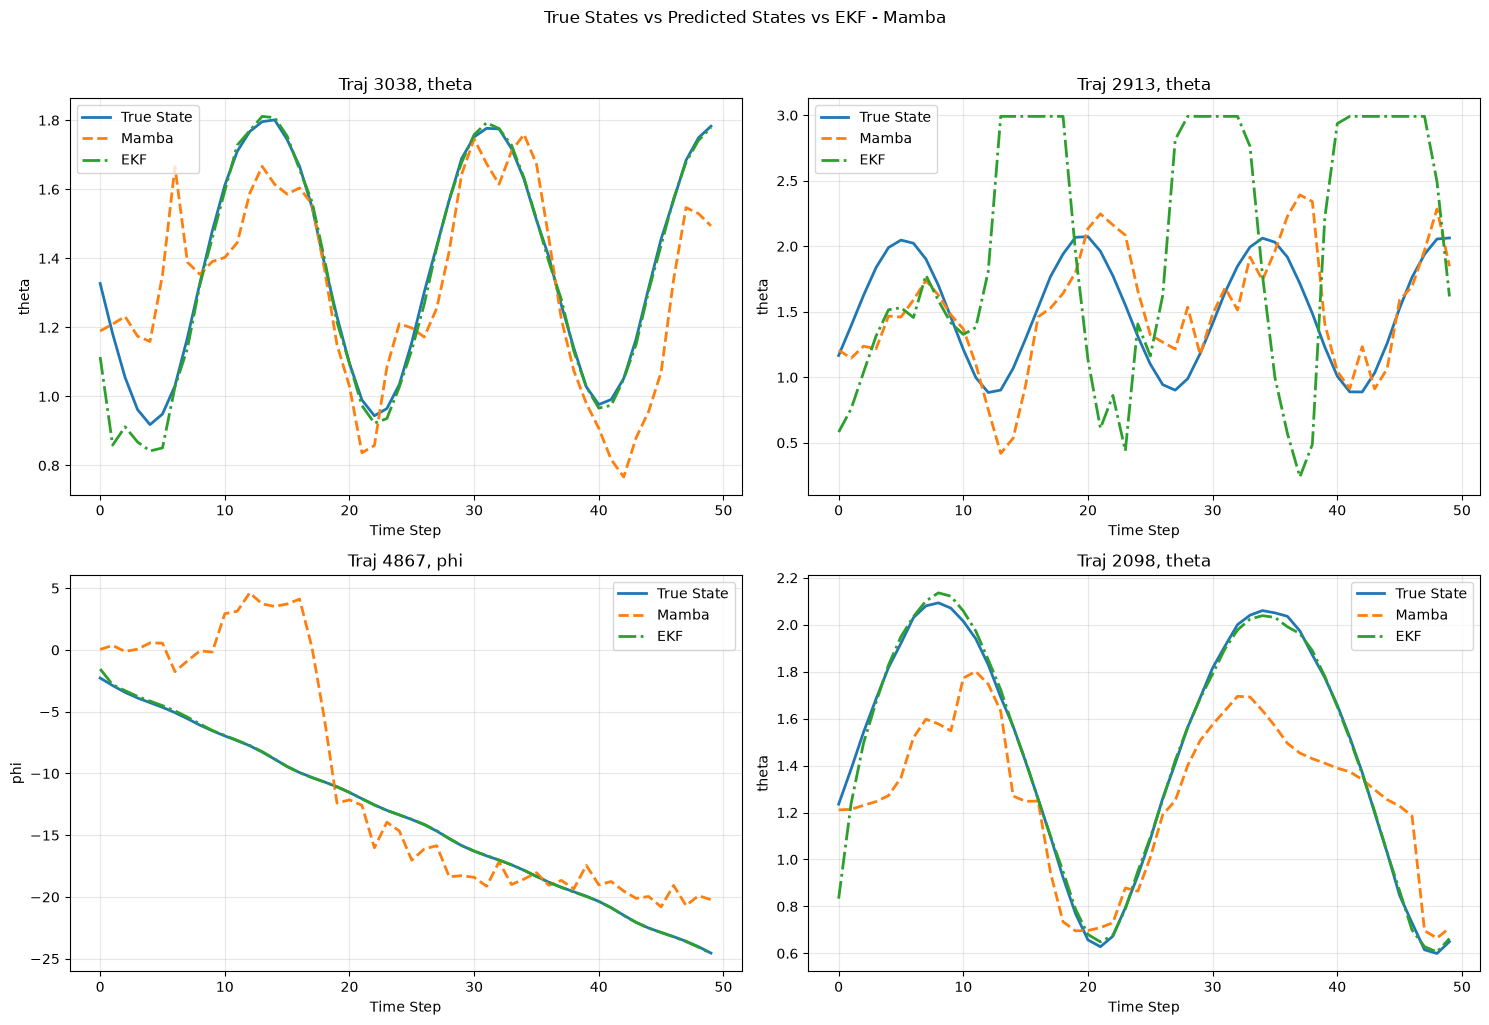

In [12]:
# 8. Example: Generate and Test Multiple Trajectories
num_trajs = CONFIG['num_test']
print(f'Generating {num_trajs} test trajectories for visualization...')
test_trajs = [
    generate_trajectory(
        ny=CONFIG['ny'],
        traj_len=CONFIG['traj_len'],
        sigma_w=CONFIG['sigma_w_test'],
        sigma_v=CONFIG['sigma_v_test'],
        m_low=CONFIG['m_low_test'],
        m_high=CONFIG['m_high_test'],
        g_low=CONFIG['g_low_test'],
        g_high=CONFIG['g_high_test'],
        l_low=CONFIG['l_low_test'],
        l_high=CONFIG['l_high_test'],
        dt=CONFIG['dt'],
        n_substeps=CONFIG['n_substeps'],
        theta_min_low=CONFIG['theta_min_low'],
        theta_min_high=CONFIG['theta_min_high'],
        u_mean=CONFIG['u_mean_test'],
        u_std=CONFIG['u_std_test'],
    )
    for _ in tqdm(range(num_trajs))
]

state_names = ['theta', 'phi', 'theta_dot', 'phi_dot']

# Randomly sample 4 trajectory/state combinations for the trajectory plot
sampled_indices = rng.choice(len(test_trajs), size=4, replace=False)

# Store data for trajectory plot - one plot per selected model
plot_data_by_model = {model_name: [] for model_name in trained_models.keys()}

for idx, traj_idx in enumerate(sampled_indices):
    test_traj = test_trajs[traj_idx]
    states_true = test_traj['states']
    obs = test_traj['obs']
    inputs = test_traj['inputs']

    # Prepare input for models
    xs_for_model = np.concatenate([obs[1:], inputs], axis=-1)
    xs_tensor = torch.from_numpy(xs_for_model).float().unsqueeze(0).to(device)

    # Get predictions for each trained model
    for model_name, model in trained_models.items():
        model = model.to(device)
        model.eval()
        with torch.no_grad():
            preds_tensor = model(xs_tensor)
        preds = preds_tensor.squeeze(0).cpu().numpy()

        # Get EKF predictions
        kf_states = apply_ekf_filter_from_traj(test_traj)
        kf_preds = kf_states[1:]

        # Randomly select a state dimension to plot
        nx = CONFIG['nx']
        state_dim = rng.integers(0, nx)

        # Store data for trajectory plot
        plot_data_by_model[model_name].append({
            'states_true': states_true[1:, state_dim],
            f'{model_name}_preds': preds[:, state_dim],
            'kf_preds': kf_preds[:, state_dim],
            'state_dim': state_dim,
            'traj_idx': traj_idx,
            'model_name': model_name
        })

# Create trajectory comparison plots for each selected model
for model_name in trained_models.keys():
    plot_data = plot_data_by_model[model_name]
    plt.figure(figsize=(15, 10))
    model_display_name = model_name.capitalize()
    for idx, data in enumerate(plot_data):
        plt.subplot(2, 2, idx+1)
        plt.plot(data['states_true'], label='True State', linewidth=2)
        plt.plot(data[f'{model_name}_preds'], '--', label=model_display_name, linewidth=2)
        plt.plot(data['kf_preds'], '-.', label='EKF', linewidth=2)
        plt.xlabel('Time Step')
        plt.ylabel(state_names[data['state_dim']])
        plt.title(f'Traj {data["traj_idx"]}, {state_names[data["state_dim"]]}')
        plt.legend()
        plt.grid(True, alpha=0.3)
    plt.suptitle(f'True States vs Predicted States vs EKF - {model_display_name}', y=1.02)
    plt.tight_layout()
    plt.show()

Computing per-timestep summed L2 norm across all 5000 trajectories...


100%|██████████| 5000/5000 [01:55<00:00, 43.13it/s] 



Average Summed L2 Error across ALL 5000 trajectories:
Mistral: 533.228
GPT2: 540.444
Mamba: 543.933
EKF: 27680556.000


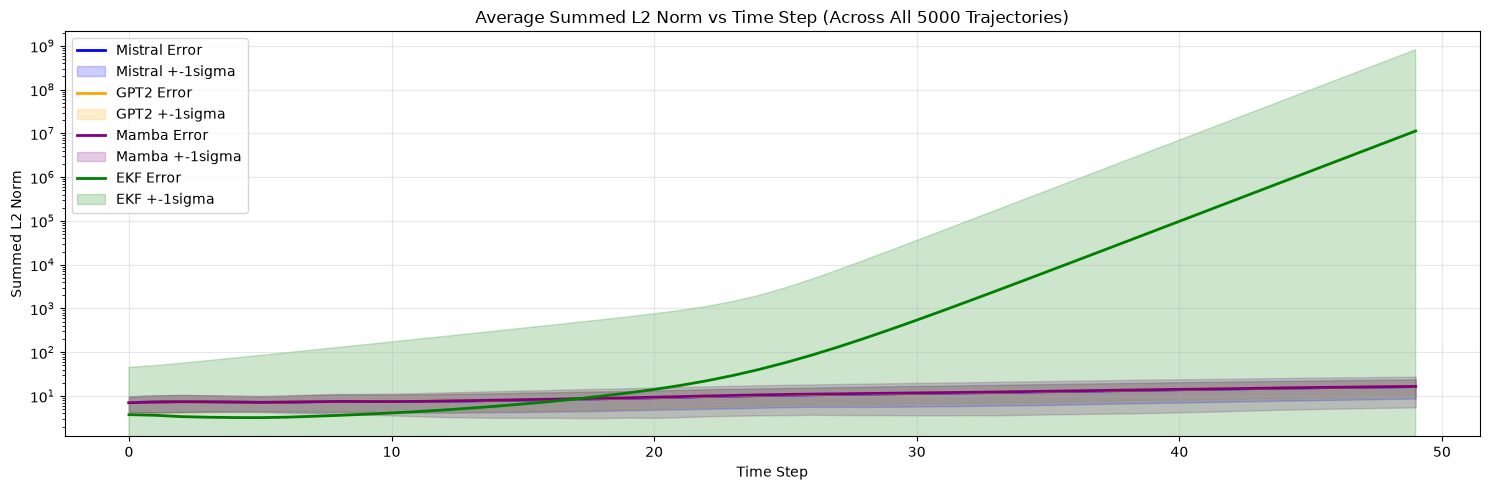

In [13]:
# Compute per-timestep summed L2 norm across ALL trajectories for each selected model
print(f'Computing per-timestep summed L2 norm across all {num_trajs} trajectories...')

# Initialize error storage for each model
all_per_timestep_l2_norms = {model_name: [] for model_name in trained_models.keys()}
all_kf_per_timestep_l2_norms = []

for test_traj in tqdm(test_trajs):
    states_true = test_traj['states']
    obs = test_traj['obs']
    inputs = test_traj['inputs']

    # Prepare input for models
    xs_for_model = np.concatenate([obs[1:], inputs], axis=-1)
    xs_tensor = torch.from_numpy(xs_for_model).float().unsqueeze(0).to(device)

    # Get predictions for each trained model
    for model_name, model in trained_models.items():
        model = model.to(device)
        model.eval()
        with torch.no_grad():
            preds_tensor = model(xs_tensor)
        preds = preds_tensor.squeeze(0).cpu().numpy()
        actual_pred_len = preds.shape[0]
        actual_state_len = min(actual_pred_len, states_true[:-1].shape[0])

        # Compute per-timestep L2 norm
        per_timestep_err = np.linalg.norm((states_true[1:][:actual_state_len] - preds[:actual_state_len]), axis=-1)
        all_per_timestep_l2_norms[model_name].append(per_timestep_err)

    # Get EKF predictions
    kf_states = apply_ekf_filter_from_traj(test_traj)
    kf_preds = kf_states[1:]
    kf_pred_len = min(kf_preds.shape[0], states_true[:-1].shape[0])
    kf_per_timestep_err = np.linalg.norm((states_true[1:][:kf_pred_len] - kf_preds[:kf_pred_len]), axis=-1)
    all_kf_per_timestep_l2_norms.append(kf_per_timestep_err)

    # Compute average and std per-timestep error for each model
model_avg_errors = {}
model_std_errors = {}

for model_name in trained_models.keys():
    min_length = min(len(err_curve) for err_curve in all_per_timestep_l2_norms[model_name])
    trimmed_errs = [err_curve[:min_length] for err_curve in all_per_timestep_l2_norms[model_name]]
    model_avg_errors[model_name] = np.mean(trimmed_errs, axis=0)
    model_std_errors[model_name] = np.std(trimmed_errs, axis=0)

# Compute average and std per-timestep error for Kalman filter
kf_min_length = min(len(err_curve) for err_curve in all_kf_per_timestep_l2_norms)
trimmed_kf_errs = [err_curve[:kf_min_length] for err_curve in all_kf_per_timestep_l2_norms]
avg_kf_per_timestep_err = np.mean(trimmed_kf_errs, axis=0)
std_kf_per_timestep_err = np.std(trimmed_kf_errs, axis=0)

# Compute overall average error across all trajectories
model_traj_errors = {}
for model_name in trained_models.keys():
    traj_errs_sum = np.array([err_curve.sum() for err_curve in all_per_timestep_l2_norms[model_name]])
    model_traj_errors[model_name] = traj_errs_sum.mean()

kf_traj_errs_sum = np.array([err_curve.sum() for err_curve in all_kf_per_timestep_l2_norms])
avg_kf_err_all = kf_traj_errs_sum.mean()

# Create Figure 2: Error vs time step plot
plt.figure(figsize=(15, 5))

# Define colors for different models
model_colors = {'mistral': 'blue', 'gpt2': 'orange', 'mamba': 'purple'}
model_names_display = {'mistral': 'Mistral', 'gpt2': 'GPT2', 'mamba': 'Mamba'}

# Plot each selected model
for model_name in trained_models.keys():
    color = model_colors.get(model_name, 'gray')
    display_name = model_names_display.get(model_name, model_name)
    min_len = min(len(err_curve) for err_curve in all_per_timestep_l2_norms[model_name])

    plt.semilogy(model_avg_errors[model_name], label=f'{display_name} Error', linewidth=2, color=color)
    plt.fill_between(
        range(min_len),
        model_avg_errors[model_name] - model_std_errors[model_name],
        model_avg_errors[model_name] + model_std_errors[model_name],
        color=color,
        alpha=0.2,
        label=f'{display_name} +-1sigma'
    )

# Plot Kalman filter
plt.semilogy(avg_kf_per_timestep_err, label='EKF Error', linewidth=2, color='green')
plt.fill_between(
    range(kf_min_length),
    avg_kf_per_timestep_err - std_kf_per_timestep_err,
    avg_kf_per_timestep_err + std_kf_per_timestep_err,
    color='green',
    alpha=0.2,
    label='EKF +-1sigma'
)
plt.xlabel('Time Step')
plt.ylabel('Summed L2 Norm')
plt.title(f'Average Summed L2 Norm vs Time Step (Across All {num_trajs} Trajectories)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Print overall average errors
print(f'\nAverage Summed L2 Error across ALL {num_trajs} trajectories:')
for model_name in trained_models.keys():
    display_name = model_names_display.get(model_name, model_name)
    print(f'{display_name}: {model_traj_errors[model_name]:.3f}')
print(f'EKF: {avg_kf_err_all:.3f}')


Finding best and worst state-trajectory pairs across 5000 trajectories...


100%|██████████| 5000/5000 [01:53<00:00, 44.21it/s] 



Mistral - Best 2 pairs:
  Traj 4106, State 0, MSE = 0.0067
  Traj 1137, State 0, MSE = 0.0073
Mistral - Worst 2 pairs:
  Traj 4092, State 1, MSE = 1189.0298
  Traj 2476, State 1, MSE = 1109.2830

GPT2 - Best 2 pairs:
  Traj 2088, State 0, MSE = 0.0085
  Traj 2490, State 0, MSE = 0.0097
GPT2 - Worst 2 pairs:
  Traj 4092, State 1, MSE = 801.8959
  Traj 4147, State 1, MSE = 609.5195

Mamba - Best 2 pairs:
  Traj 1820, State 0, MSE = 0.0072
  Traj 4260, State 0, MSE = 0.0123
Mamba - Worst 2 pairs:
  Traj 4092, State 1, MSE = 1488.7671
  Traj 1136, State 1, MSE = 1422.4932


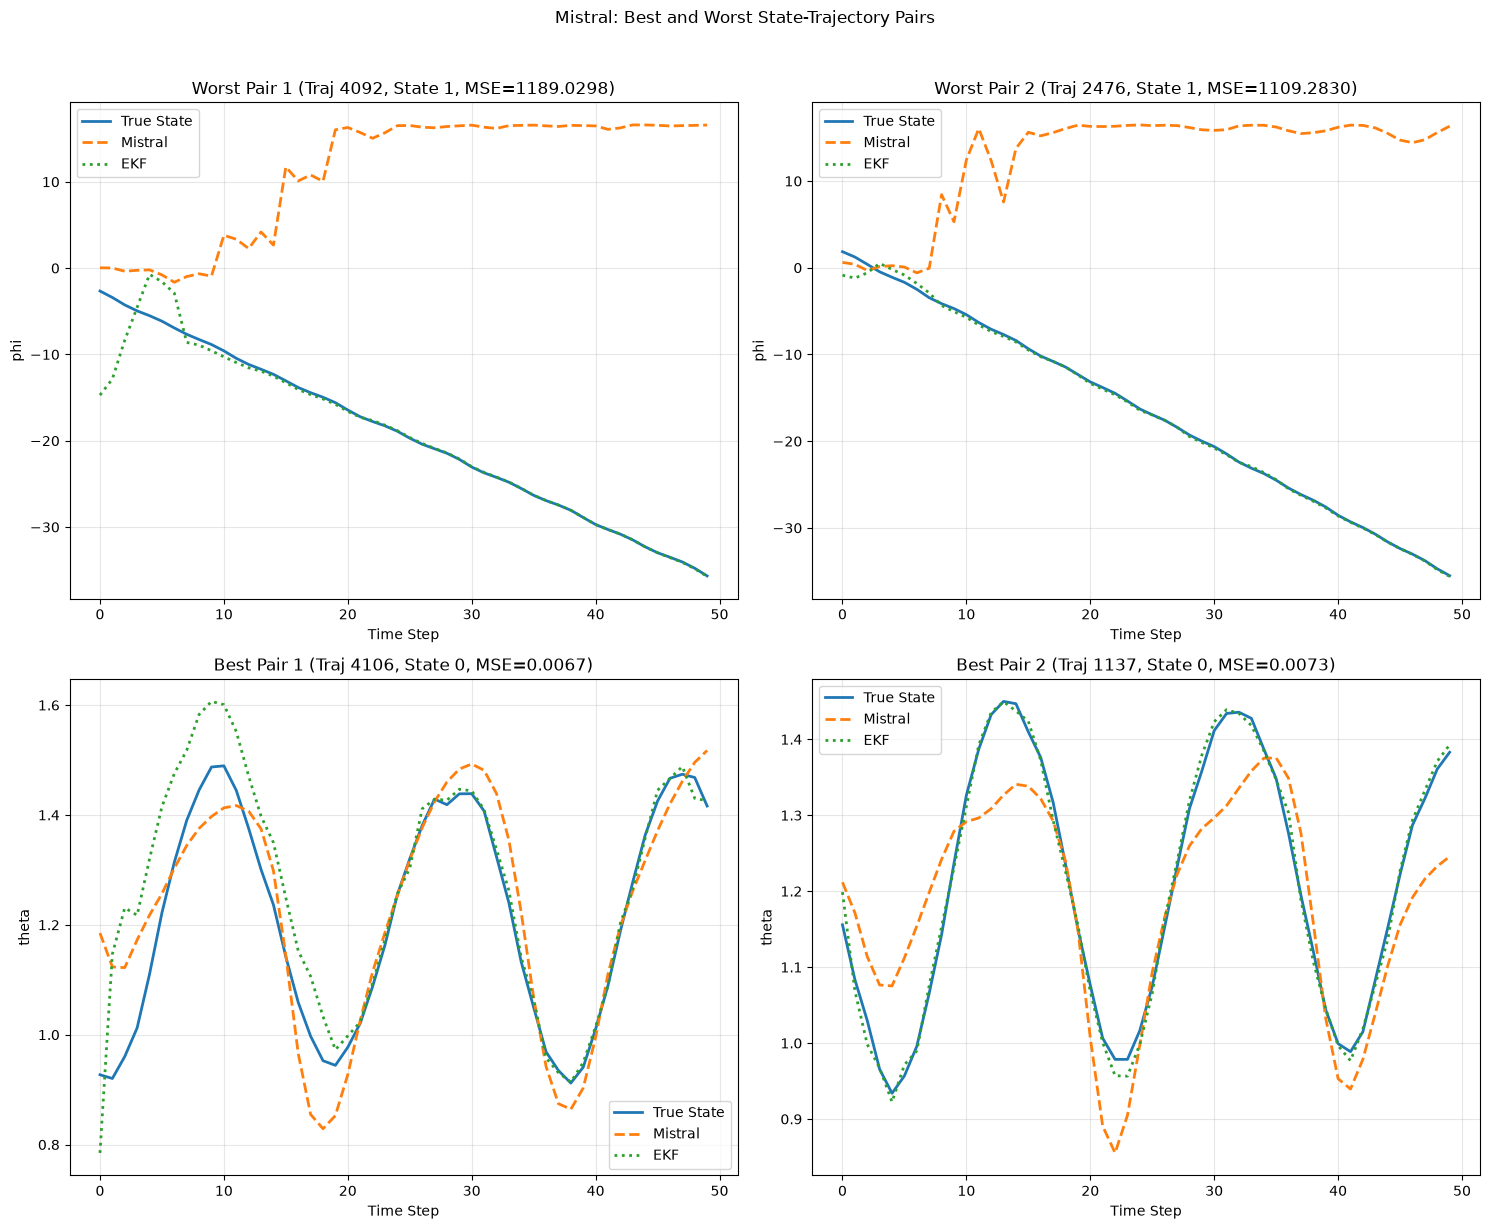

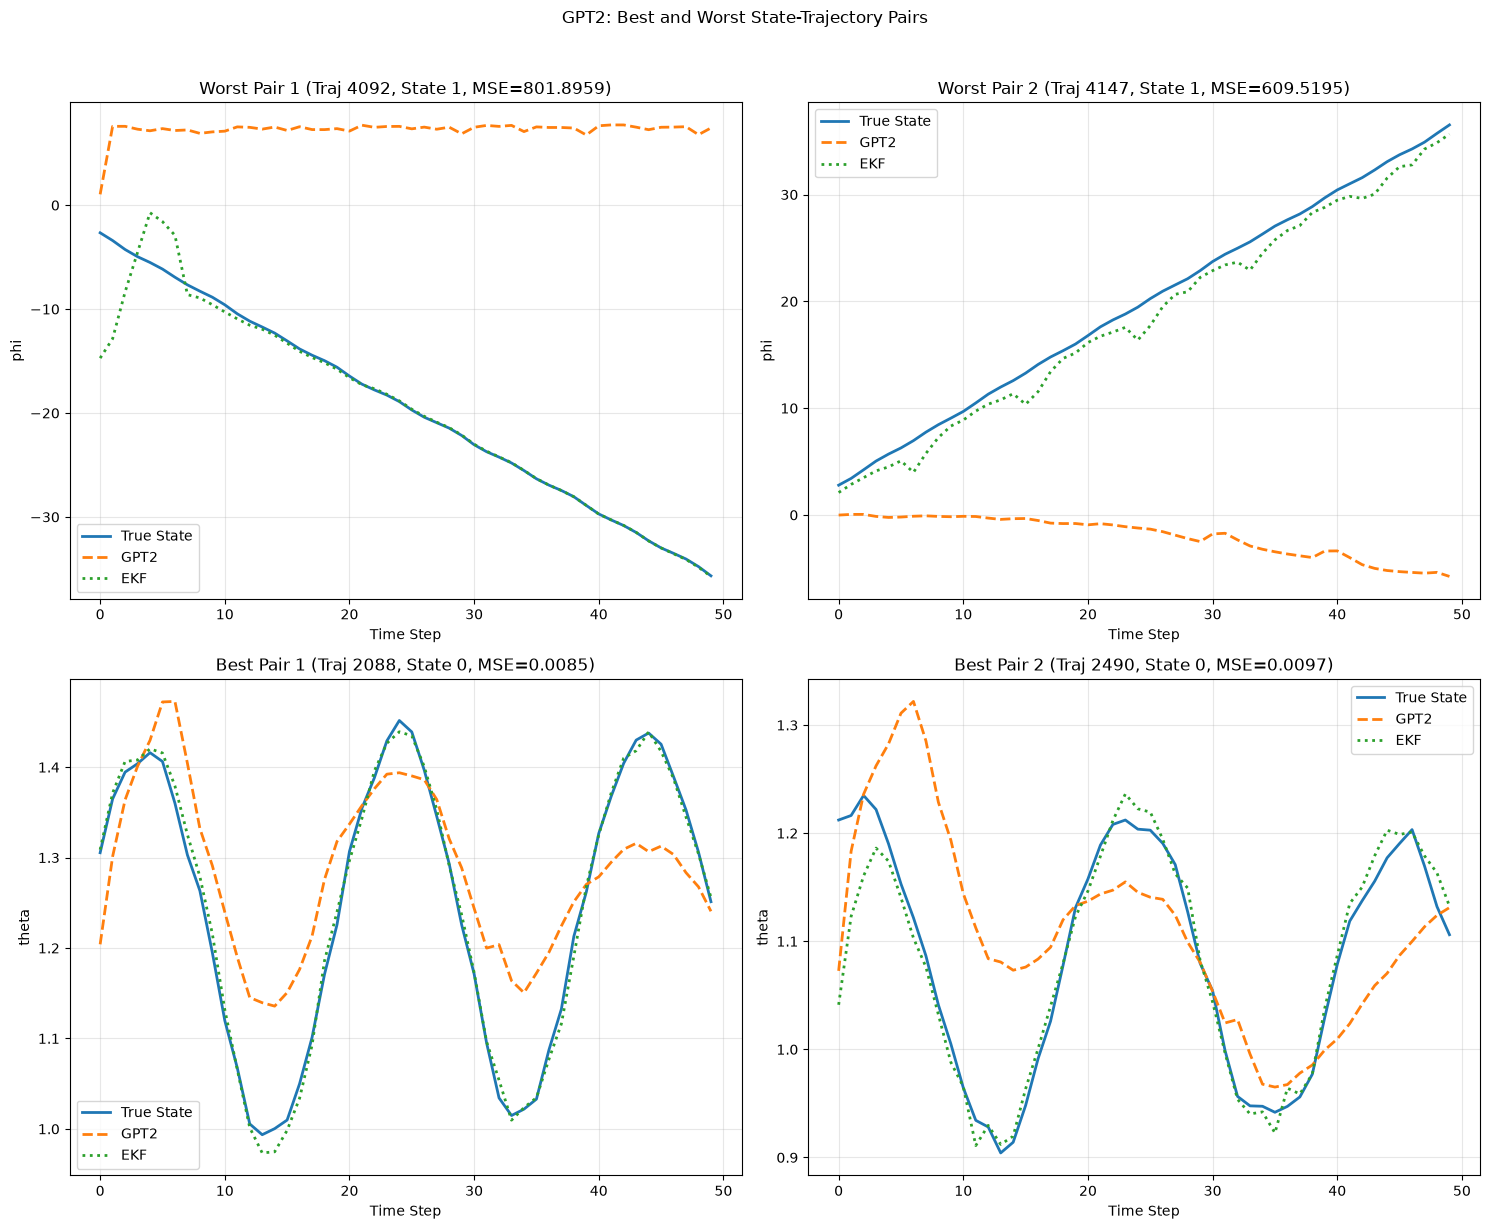

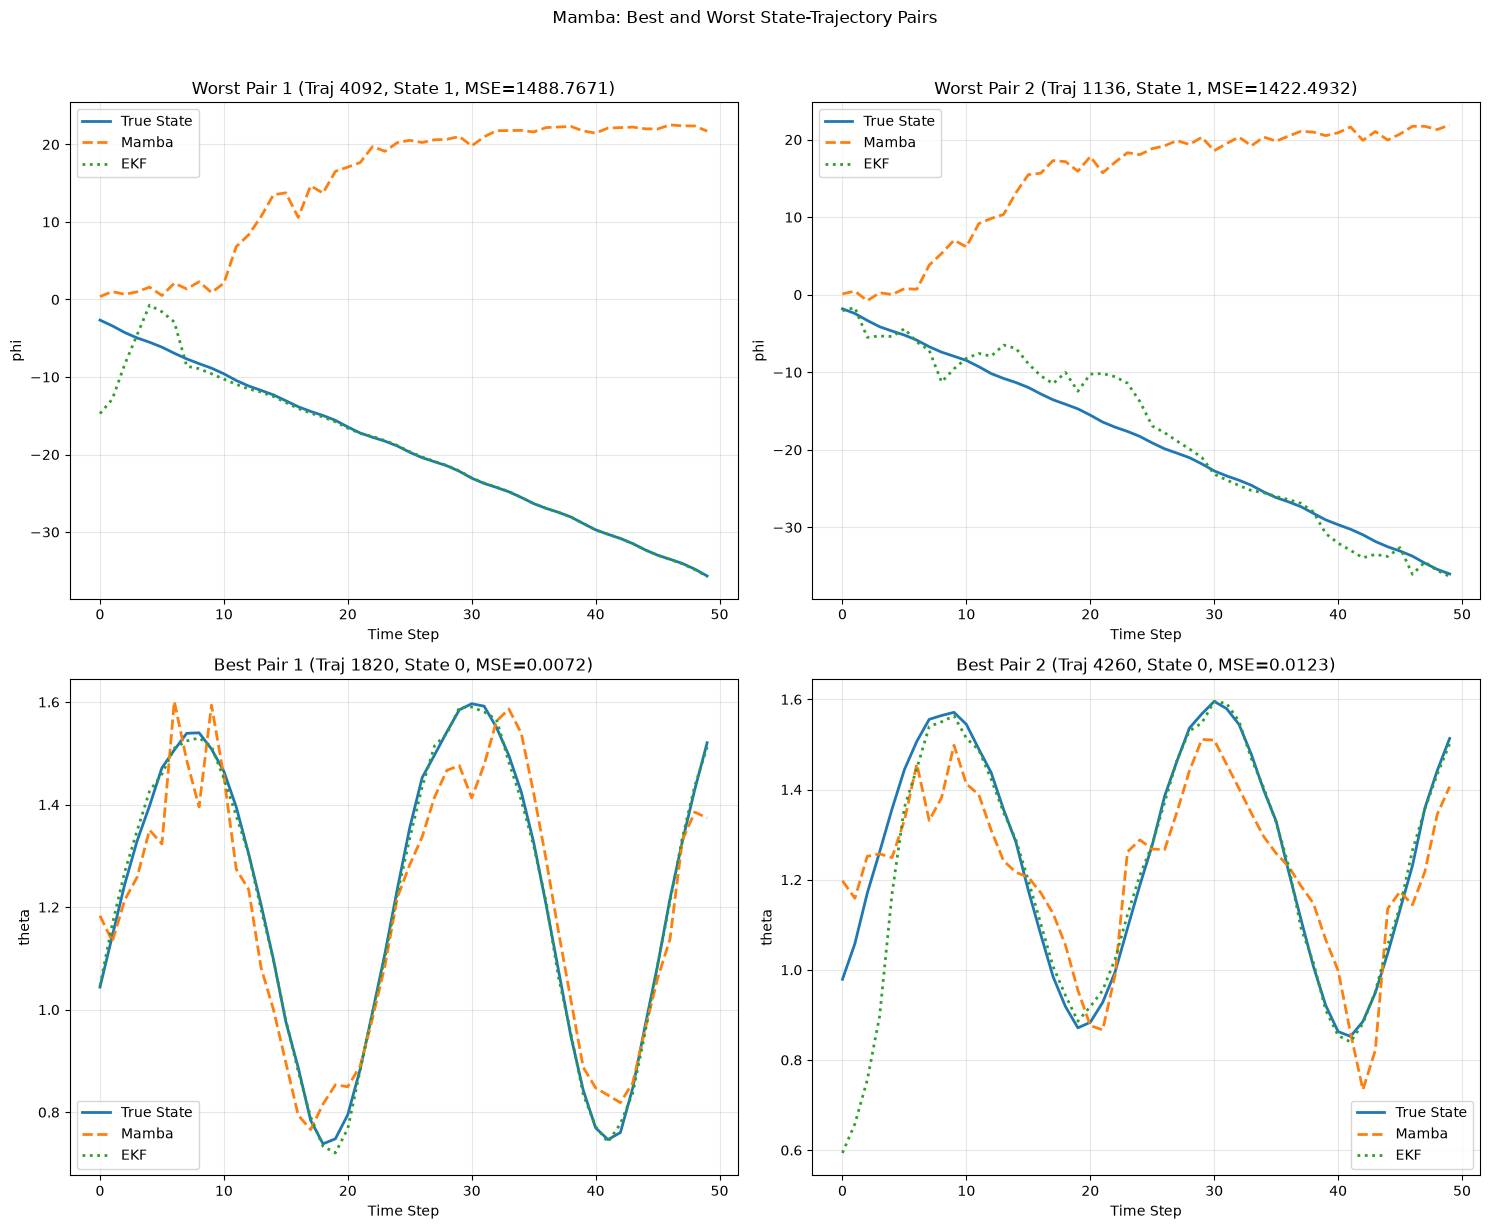

In [14]:
# Find 2 best and 2 worst-performing state-trajectory pairs across ALL test trajectories for each selected model
print(f'Finding best and worst state-trajectory pairs across {num_trajs} trajectories...')

# Initialize storage for best and worst pairs for all methods
model_best_pairs = {model_name: [] for model_name in trained_models.keys()}
model_worst_pairs = {model_name: [] for model_name in trained_models.keys()}

for traj_idx, test_traj in enumerate(tqdm(test_trajs)):
    states_true = test_traj['states']
    obs = test_traj['obs']
    inputs = test_traj['inputs']

    # Prepare input for models
    xs_for_model = np.concatenate([obs[1:], inputs], axis=-1)
    xs_tensor = torch.from_numpy(xs_for_model).float().unsqueeze(0).to(device)

    # Get EKF predictions
    kf_states = apply_ekf_filter_from_traj(test_traj)
    kf_preds = kf_states[1:]

    # Get predictions for each model and find best/worst pairs
    for model_name, model in trained_models.items():
        model = model.to(device)
        model.eval()
        with torch.no_grad():
            preds_tensor = model(xs_tensor)
        preds = preds_tensor.squeeze(0).cpu().numpy()

        actual_state_len = min(preds.shape[0], states_true[:-1].shape[0], kf_preds.shape[0])

        for state_dim in range(CONFIG['nx']):
            # Compute MSE for this pair
            pair_mse = np.mean((states_true[1:][:actual_state_len, state_dim] - preds[:actual_state_len, state_dim]) ** 2)

            pair_data = (pair_mse, traj_idx, state_dim, states_true, preds, kf_preds, actual_state_len)

            # Add to best pairs (keep only top 2 lowest MSE)
            model_best_pairs[model_name].append(pair_data)
            model_best_pairs[model_name].sort(key=lambda x: x[0])  # Sort by MSE ascending
            if len(model_best_pairs[model_name]) > 2:
                model_best_pairs[model_name].pop()  # Remove worst of the best

            # Add to worst pairs (keep only top 2 highest MSE)
            model_worst_pairs[model_name].append(pair_data)
            model_worst_pairs[model_name].sort(key=lambda x: x[0], reverse=True)  # Sort by MSE descending
            if len(model_worst_pairs[model_name]) > 2:
                model_worst_pairs[model_name].pop()  # Remove best of the worst

# Print results for each model
for model_name in trained_models.keys():
    display_name = model_names_display.get(model_name, model_name)
    print(f'\n{display_name} - Best 2 pairs:')
    for mse, traj_idx, state_dim, _, _, _, _ in model_best_pairs[model_name]:
        print(f'  Traj {traj_idx}, State {state_dim}, MSE = {mse:.4f}')
    print(f'{display_name} - Worst 2 pairs:')
    for mse, traj_idx, state_dim, _, _, _, _ in model_worst_pairs[model_name]:
        print(f'  Traj {traj_idx}, State {state_dim}, MSE = {mse:.4f}')

# Create plots for each model
for model_name in trained_models.keys():
    display_name = model_names_display.get(model_name, model_name)
    all_pairs = model_worst_pairs[model_name] + model_best_pairs[model_name]
    titles = ['Worst Pair 1', 'Worst Pair 2', 'Best Pair 1', 'Best Pair 2']

    plt.figure(figsize=(15, 12))
    for idx, (mse, traj_idx, state_dim, states_true, preds, kf_preds, actual_len) in enumerate(all_pairs):
        plt.subplot(2, 2, idx + 1)
        plt.plot(states_true[1:, state_dim], label='True State', linewidth=2)
        plt.plot(preds[:actual_len, state_dim], '--', label=display_name, linewidth=2)
        plt.plot(kf_preds[:actual_len, state_dim], ':', label='EKF', linewidth=2)
        plt.xlabel('Time Step')
        plt.ylabel(state_names[state_dim])
        plt.title(f'{titles[idx]} (Traj {traj_idx}, State {state_dim}, MSE={mse:.4f})')
        plt.legend()
        plt.grid(True, alpha=0.3)
    plt.suptitle(f'{display_name}: Best and Worst State-Trajectory Pairs', y=1.02)
    plt.tight_layout()
    plt.show()

In [15]:
# 9. Save and Load Model (Optional)

def save_model(model, model_name, path=None, config=None):
    """Save the trained model."""
    if path is None:
        path = f'{model_name}_fsm_nonlinear_pendulum.pth'
    if config is None:
        config = CONFIG
    torch.save({
        'model_state_dict': model.state_dict(),
        'config': config,
        'model_type': model.__class__.__name__,
        'model_name': model_name
    }, path)
    print(f'Model saved to {path}')

def load_model(path, model_name=None, config=None):
    """Load a saved model."""
    # Handle PyTorch 2.6+ weights_only default
    import sys
    if sys.version_info >= (3, 8):  # PyTorch 2.6+ compatibility
        import torch.serialization
        torch.serialization.add_safe_globals([np._core.multiarray.scalar])
    checkpoint = torch.load(path, map_location=device, weights_only=False)

    if config is None:
        config = checkpoint.get('config', CONFIG)
    if model_name is None:
        model_name = checkpoint.get('model_name', 'mistral')

    model_type = checkpoint.get('model_type', 'Mistral7BFilter')
    input_dim = config.get('ny', 2) + config.get('nu', 2)
    output_dim = config.get('nx', 4)

    if model_type == 'Mistral7BFilter':
        model = Mistral7BFilter(
            input_dim=input_dim,
            output_dim=output_dim,
            n_positions=config.get('n_positions', 50),
            n_embd=config.get('n_embd', 128),
            n_layer=config.get('n_layer', 6),
            n_head=config.get('n_head', 4),
            dropout=config.get('gpt2_dropout', 0.15),
            learning_rate=config.get('gpt2_learning_rate', 1e-4),
            weight_decay=config.get('gpt2_weight_decay', 1e-4),
            gradient_clip=config.get('gradient_clip', 1.0)
        )
    elif model_type == 'GPT2Filter':
        model = GPT2Filter(
            input_dim=input_dim,
            output_dim=output_dim,
            n_positions=config.get('n_positions', 50),
            n_embd=config.get('gpt2_n_embd', 256),
            n_layer=config.get('gpt2_n_layer', 12),
            n_head=config.get('gpt2_n_head', 8),
            dropout=config.get('dropout', 0.1),
            learning_rate=config.get('gpt2_learning_rate', 3e-4),
            weight_decay=config.get('gpt2_weight_decay', 1e-2),
            gradient_clip=config.get('gradient_clip', 1.0)
        )
    elif model_type == 'MambaFilter':
        model = MambaFilter(
            input_dim=input_dim,
            output_dim=output_dim,
            n_positions=config.get('n_positions', 50),
            d_model=config.get('d_model', 256),
            n_layers=config.get('n_layers', 4),
            d_state=config.get('d_state', 16),
            d_conv=config.get('d_conv', 4),
            expand=config.get('expand', 2),
            learning_rate=config.get('learning_rate', 1e-4),
            weight_decay=config.get('weight_decay', 1e-4),
            gradient_clip=config.get('gradient_clip', 1.0)
        )
    else:
        raise ValueError(f'Unknown model type: {model_type}')

    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()
    print(f'Model loaded from {path}')
    return model, config, model_name

# # Save all trained models
# for model_name, model in trained_models.items():
#     save_model(model, model_name)
# print(f'All {len(trained_models)} models saved successfully!')

# Example: Load all saved models back
# Uncomment the following to load all saved models:
loaded_models = {}
for model_name in models.keys():
    try:
        loaded_model, loaded_config, loaded_model_name = load_model(f'{model_name}_fsm_nonlinear_pendulum.pth')
        loaded_models[model_name] = loaded_model
        print(f'Loaded {model_name} model successfully')
    except FileNotFoundError:
        print(f'No saved model found for {model_name}')
    except Exception as e:
        print(f'Error loading {model_name} model: {e}')
trained_models = loaded_models
print(f'Loaded {len(loaded_models)} models successfully')


No saved model found for mistral
No saved model found for gpt2
No saved model found for mamba
Loaded 0 models successfully
